---
## Paso 1: Carga del conjunto de datos


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

%pip install statsmodels pmdarima

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

# Carga del dataset
url = 'https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv'
df_raw = pd.read_csv(url)
print('Dataset cargado')


print(f'\nShape: {df_raw.shape}')
df_raw.head()

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset cargado

Shape: (366, 2)


,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


---
## Paso 2: Construcción y análisis de la serie temporal

Para que statsmodels y pmdarima reconozcan los datos como serie temporal necesitamos:
1. Convertir la columna de fecha a datetime
2. Establecerla como índice
3. Asignar la frecuencia correcta MS = Month Start

Después analizaremos los cuatro aspectos clave: tensor, tendencia, estacionariedad y variabilidad/ruido.

In [30]:
#Construcción de la estructura de serie temporal
df = df_raw.copy()
df['date'] = pd.to_datetime(df['date'])#convertimos a datetime
df = df.set_index('date')#fecha como índice

#En lugar de asignar freq a mano, resampleamos a mensual
#sum() si las fechas son diarias, mean() si ya son mensuales pero con día variable
df = df.resample('MS').sum()

ts = df['sales']

#Esto elimina el último mes si su valor es menos de la mitad del anterior,he puesto esto porque septiembre no tiene datos completos,de 2023,solo unos pocos dias
#y me salia en las graficas una bajada de las ventas muy rara,y era por eso,y es porque en el dataset septiemhbre de 2023
#esta imcompleto,asi que lo he elimanado para que no se vea rara la grafica
if ts.iloc[-1] < ts.iloc[-2] * 0.5:
    ts = ts.iloc[:-1]
    print("Último mes incompleto eliminado")

print('Tipo del índice:',type(ts.index))
print('Frecuencia:',ts.index.freq)
print('Rango temporal:',ts.index.min().date(), '->', ts.index.max().date())
print('Número de obs:',len(ts))
ts.head()

Último mes incompleto eliminado
Tipo del índice: <class 'pandas.DatetimeIndex'>
Frecuencia: <MonthBegin>
Rango temporal: 2022-09-01 -> 2023-08-01
Número de obs: 12


date
2022-09-01     2414.686283
2022-10-01     5003.489725
2022-11-01     7222.754628
2022-12-01     9990.371237
2023-01-01    12450.943431
Freq: MS, Name: sales, dtype: float64

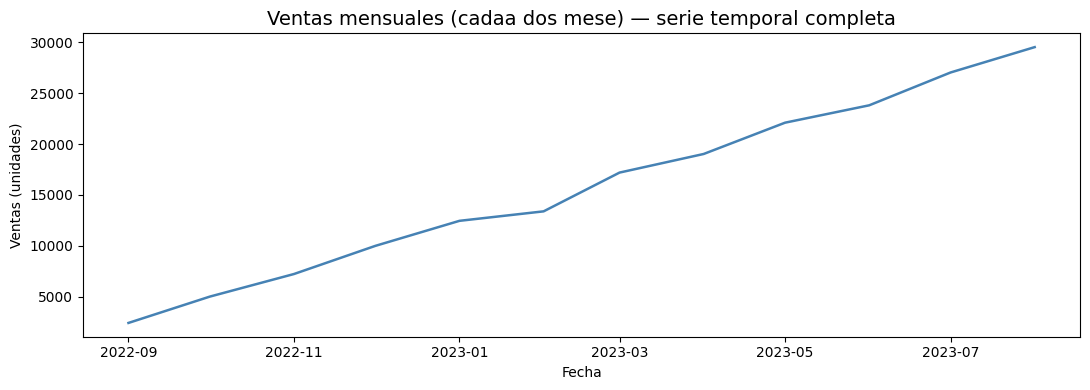

In [31]:
#Gráfico de la serie temporal completa
fig, axis = plt.subplots(figsize=(11, 4))

sns.lineplot(data=ts, color='steelblue', linewidth=1.8)
axis.set_title('Ventas mensuales (cadaa dos mese) — serie temporal completa', fontsize=14)
axis.set_xlabel('Fecha')
axis.set_ylabel('Ventas (unidades)')

plt.tight_layout()
plt.show()

### 2.1 Tensor de la serie temporal


In [11]:
#Inspeccionamos la frecuencia del índice
print('Frecuencia del índice:', ts.index.freq)
print('Diferencia entre obs consecutivas:', ts.index[1] - ts.index[0])
print()
print('Tensor:mensual(una observación por mes)')
print('Cada fila representa el total de ventas de un mes completo.')

Frecuencia del índice: <MonthBegin>
Diferencia entre obs consecutivas: 30 days 00:00:00

Tensor:mensual(una observación por mes)
Cada fila representa el total de ventas de un mes completo.


### 2.2 Tendencia


In [32]:
# Con pocos meses usamos period=6 en lugar de 12
decomposition = seasonal_decompose(ts, model='additive', period=6)

trend    = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

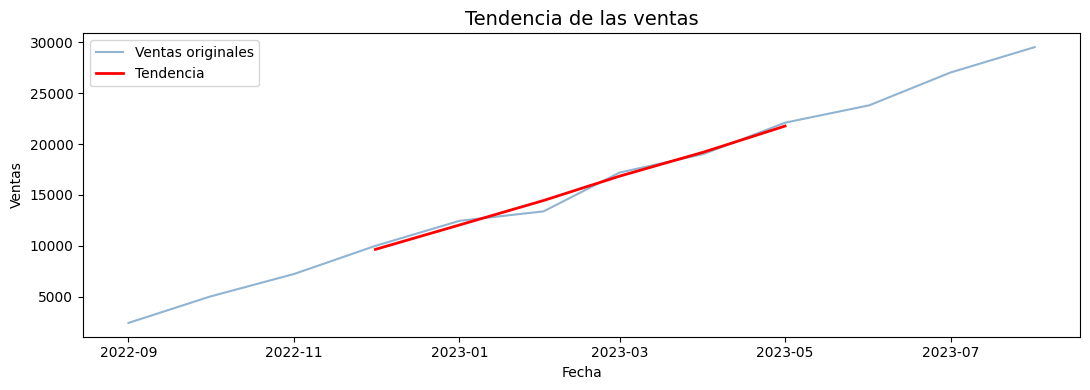

In [33]:
fig, axis = plt.subplots(figsize=(11, 4))

sns.lineplot(data=ts,    label='Ventas originales', color='steelblue', alpha=0.6)
sns.lineplot(data=trend, label='Tendencia',         color='red',       linewidth=2)

axis.set_title('Tendencia de las ventas', fontsize=14)
axis.set_xlabel('Fecha')
axis.set_ylabel('Ventas')
axis.legend()

plt.tight_layout()
plt.show()

### 2.3 ¿Es estacionaria?

Una serie es estacionaria cuando su media y varianza son constantes a lo largo del tiempo (no tiene tendencia ni estacionalidad sistemática).

Utilizamos el test de Dickey-Fuller aumentado (ADF):
- Si el p-valor < 0.05 -> rechazamos H₀ → la serie es estacionaria
- Si el p-valor ≥ 0.05 -> no rechazamos H₀ → la serie NO es estacionaria

In [34]:
def test_stationarity(timeseries, label=''):
    #Aplica el test ADF e imprime los resultados formateados.
    print(f'Test de Dickey-Fuller Aumentado {label} ')
    dftest    = adfuller(timeseries.dropna(), autolag='AIC')
    dfoutput  = pd.Series(
        dftest[0:4],
        index=['Test Statistic', 'p-value', '#Lags Used', 'Num. Observations']
    )
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    return dfoutput



In [35]:
result_original = test_stationarity(ts, '(serie original)')
display(result_original)

p_val = result_original['p-value']
if p_val < 0.05:
    print(f'\np-valor = {p_val:.4f} < 0.05 -> La serie ES estacionaria')
else:
    print(f'\np-valor = {p_val:.4f} ≥ 0.05 -> La serie NO es estacionaria')

Test de Dickey-Fuller Aumentado (serie original) 


Test Statistic          7.514466
p-value                 1.000000
#Lags Used              4.000000
Num. Observations       7.000000
Critical Value (1%)    -4.938690
Critical Value (5%)    -3.477583
Critical Value (10%)   -2.843868
dtype: float64


p-valor = 1.0000 ≥ 0.05 -> La serie NO es estacionaria


### 2.4 ¿Existe variabilidad o presencia de ruido?

Analizamos el componente de residuos (resid) de la descomposición. Si la descomposición es buena, los residuos deben parecerse a ruido aleatorio: sin tendencia, sin patrones periódicos y sin correlaciones.

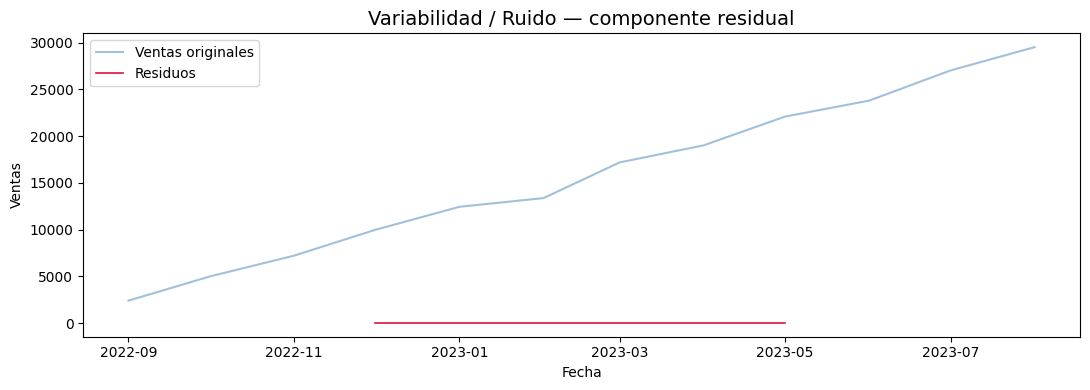

Desviación estándar del residuo : 0.00
Media del residuo               : 31.27



In [ ]:
fig, axis = plt.subplots(figsize=(11, 4))

sns.lineplot(data=ts,       label='Ventas originales', color='steelblue', alpha=0.5)
sns.lineplot(data=residual, label='Residuos',          color='crimson',   linewidth=1.2)

axis.set_title('Variabilidad / Ruido — componente residual', fontsize=14)
axis.set_xlabel('Fecha')
axis.set_ylabel('Ventas')
axis.legend()

plt.tight_layout()
plt.show()

print(f'Desviación estándar del residuo:{residual.std():.2f}')
print(f'Media del residuo:{residual.mean():.2f}')
print()

---
## Paso 3: Entrenamiento del modelo ARIMA


In [ ]:
#Solo 2 meses de test porque el dataset es pequeño
HORIZON = 2

train = ts[:-HORIZON]
test  = ts[-HORIZON:]

print(f'Train:{len(train)} obs  ({train.index.min().date()} → {train.index.max().date()})')
print(f'Test:{len(test)}  obs  ({test.index.min().date()} → {test.index.max().date()})')

Train: 10 obs  (2022-09-01 → 2023-06-01)
Test : 2  obs  (2023-07-01 → 2023-08-01)


In [38]:
#auto_arima: búsqueda automática de los mejores parámetros
#trace=True      → muestra en pantalla todos los modelos evaluados
#stepwise=True   → búsqueda eficiente (no exhaustiva)

model = auto_arima(
    train,
    seasonal          = False,  # sin estacionalidad, pocos datos
    trace             = True,
    stepwise          = True,
    suppress_warnings = True
)

print(f'\nMejor modelo:ARIMA{model.order}')
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=222.603, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=192.655, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=221.357, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=185.607, Time=0.04 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=181.307, Time=0.06 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=180.819, Time=0.11 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=8520.093, Time=0.43 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.14 sec

Best model:  ARIMA(3,0,1)(0,0,0)[0]          
Total fit time: 1.032 seconds

Mejor modelo:ARIMA(3, 0, 1)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   10
Model:               SARIMAX(3, 0, 1)   Log Likelihood

---
## Paso 4: Predicción sobre el conjunto de test


In [39]:
forecast = model.predict(len(test))  
forecast

2023-07-01    26488.346887
2023-08-01    28515.441715
Freq: MS, dtype: float64

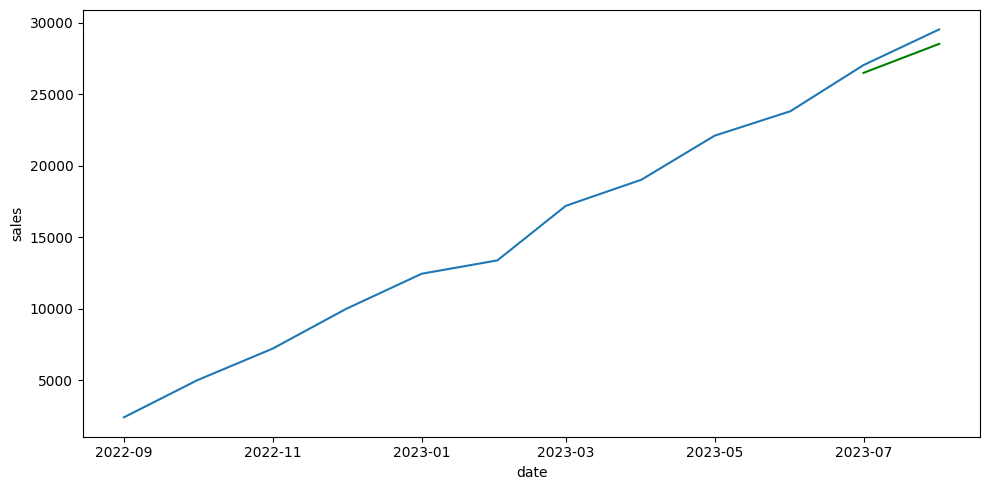

In [40]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts)
sns.lineplot(data = forecast, c = "green")

plt.tight_layout()

plt.show()